In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import os

!pip install -q kaggle

!mkdir -p ~/.kaggle

!cp "/content/kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key configured.")

Kaggle API key configured.


In [3]:

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/

print("Dataset downloaded.")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:30<00:00, 79.8MB/s]

Dataset downloaded.


In [4]:

!unzip -q /content/chest-xray-pneumonia.zip -d /content/

print("Dataset unzipped to /content/chest_xray.")

!ls /content/chest_xray/chest_xray/train
!ls /content/chest_xray/chest_xray/test


Dataset unzipped to /content/chest_xray.
NORMAL	PNEUMONIA
NORMAL	PNEUMONIA


The Kaggle dataset typically extracts into a nested directory like `/content/chest_xray/chest_xray`. We need to adjust `train_path` and `test_path` accordingly.

In [5]:
train_path = "/content/chest_xray/chest_xray/train"
test_path  = "/content/chest_xray/chest_xray/test"

print(f"Updated train_path: {train_path}")
print(f"Updated test_path: {test_path}")

Updated train_path: /content/chest_xray/chest_xray/train
Updated test_path: /content/chest_xray/chest_xray/test


In [6]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [7]:
model = Sequential()


model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))


model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))


model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 718s 4s/step - accuracy: 0.8196 - loss: 0.3899 - val_accuracy: 0.8173 - val_loss: 0.4586
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 725s 4s/step - accuracy: 0.9074 - loss: 0.2240 - val_accuracy: 0.8478 - val_loss: 0.4229
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 707s 4s/step - accuracy: 0.9227 - loss: 0.2006 - val_accuracy: 0.8333 - val_loss: 0.4424
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 734s 5s/step - accuracy: 0.9250 - loss: 0.1925 - val_accuracy: 0.7933 - val_loss: 0.5850
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 734s 5s/step - accuracy: 0.9239 - loss: 0.1888 - val_accuracy: 0.8349 - val_loss: 0.4611
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 704s 4s/step - accuracy: 0.9325 - loss: 0.1695 - val_accuracy: 0.8670 - val_loss: 0.4001
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 718s 4s/step - accuracy: 0.9398 - loss: 0.1588 - val_accuracy: 0.7869 - val_loss: 0.6425
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 750s 5s/step - accuracy: 0.9383 - loss: 0.1592 - val_accu

In [10]:
loss, acc = model.evaluate(test_data)
print("Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8622 - loss: 0.4218
Accuracy: 0.8621794581413269


20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step


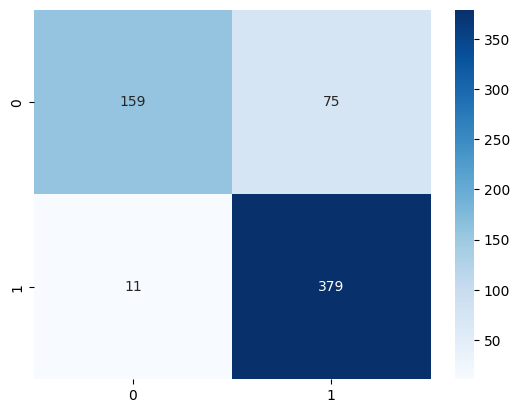

In [11]:
preds = model.predict(test_data)
preds = (preds > 0.5).astype(int)

cm = confusion_matrix(test_data.classes, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [12]:
print(classification_report(
    test_data.classes,
    preds,
    target_names=['NORMAL','PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.94      0.68      0.79       234
   PNEUMONIA       0.83      0.97      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.83      0.84       624
weighted avg       0.87      0.86      0.86       624



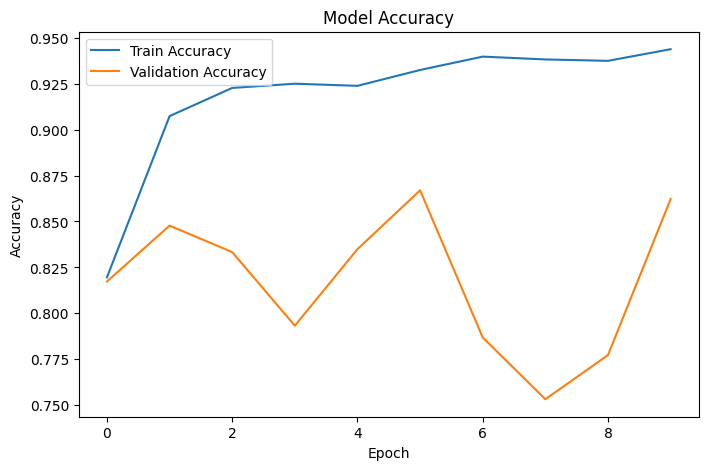

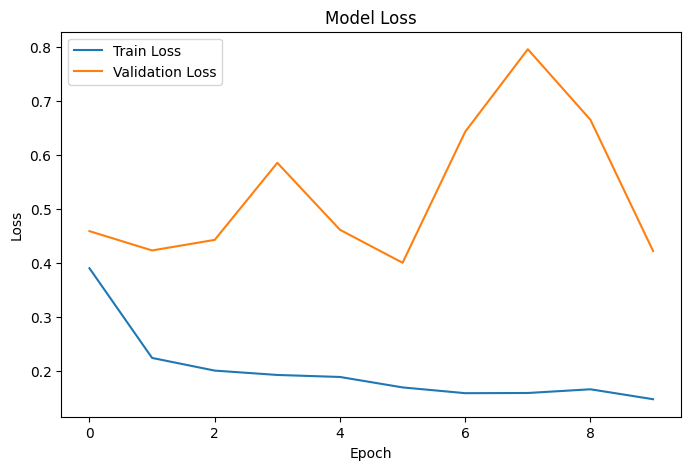

In [13]:

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

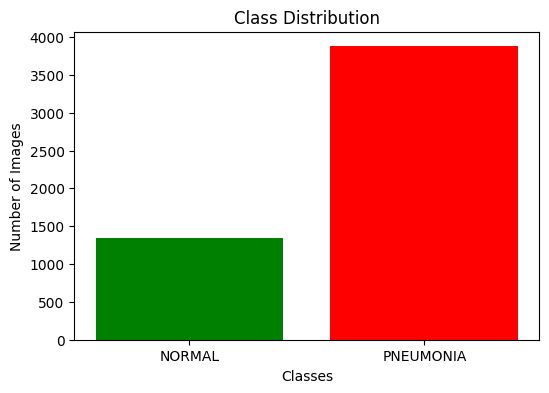

In [14]:
import os

labels = ["NORMAL", "PNEUMONIA"]
counts = [len(os.listdir(os.path.join(train_path, c))) for c in labels]

plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=['green','red'])
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

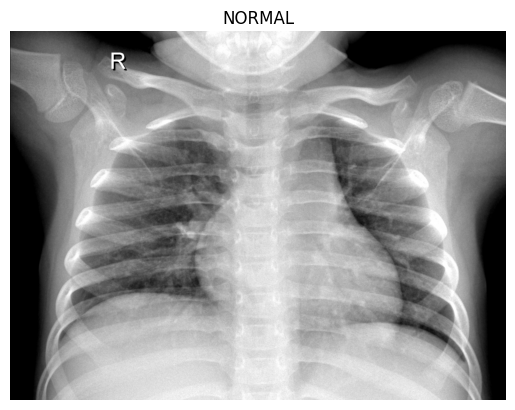

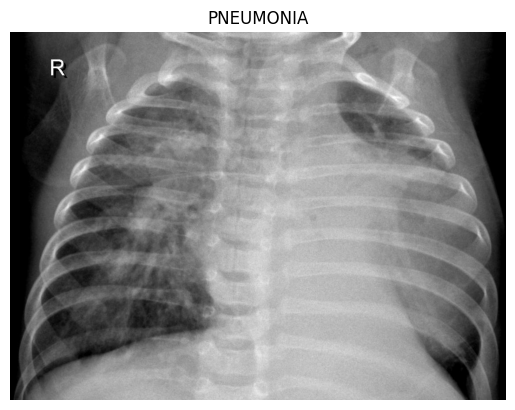

In [15]:
import random
from tensorflow.keras.preprocessing.image import load_img

for category in ["NORMAL", "PNEUMONIA"]:
    path = os.path.join(train_path, category)
    img_path = os.path.join(path, random.choice(os.listdir(path)))

    img = load_img(img_path)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')
    plt.show()

In [16]:
!pip install shap

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


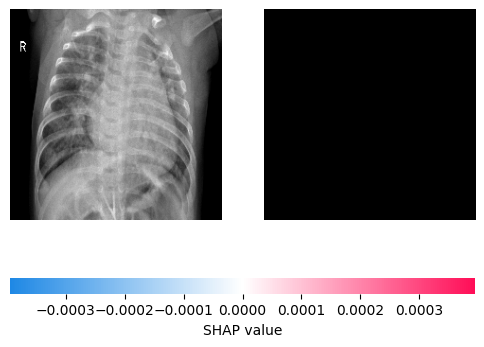

In [21]:
import os
import random
from tensorflow.keras.preprocessing.image import load_img
import numpy as np
import shap

folder = "/content/chest_xray/test/PNEUMONIA"

img_name = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_name)

img = load_img(img_path, target_size=(224,224))
img_array = np.expand_dims(np.array(img)/255.0, axis=0)
uld get it from `next(train_data)`
explainer = shap.GradientExplainer(model, background_images)

shap_values = explainer.shap_values(img_array)

shap.image_plot(shap_values, img_array)

In [22]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=027f075e4542abde92651bd7d774ca903472560ed48ee3496d171af07626bc21
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

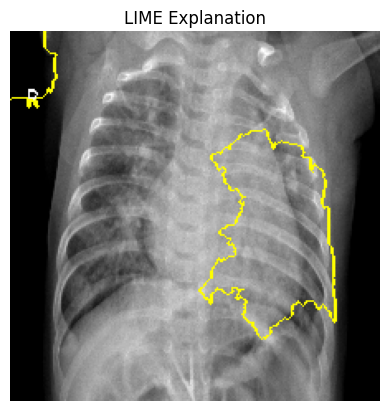

In [23]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np

explainer = lime_image.LimeImageExplainer()

def predict_fn(images):
    images = images / 255.0
    return model.predict(images)

explanation = explainer.explain_instance(
    np.array(img),
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis('off')
plt.show()

Found categories in /content/chest_xray/test: ['NORMAL', 'PNEUMONIA']


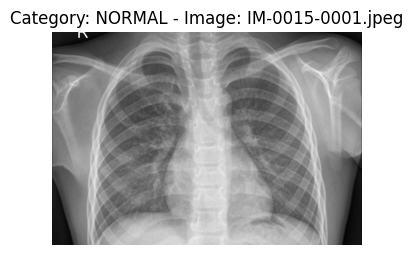

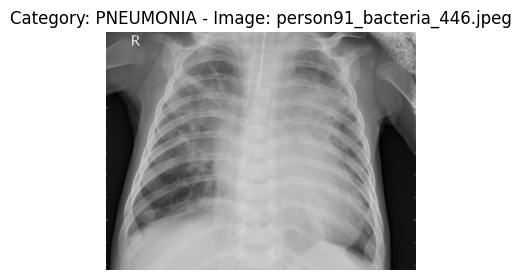

In [26]:
import os
import random
from tensorflow.keras.preprocessing.image import load_img
import matplotlib.pyplot as plt

test_base_dir = "/content/chest_xray/test"

categories = os.listdir(test_base_dir)

print(f"Found categories in {test_base_dir}: {categories}")

for category in categories:
    category_path = os.path.join(test_base_dir, category)
    if os.path.isdir(category_path):
        image_files = os.listdir(category_path)
        if image_files:

            random_image_name = random.choice(image_files)
            image_full_path = os.path.join(category_path, random_image_name)


            img = load_img(image_full_path)


            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.title(f"Category: {category} - Image: {random_image_name}")
            plt.axis('off')
            plt.show()
        else:
            print(f"No images found in category: {category}")
    else:
        print(f"Skipping {category} as it's not a directory.")